In [1]:
# --- CELL 1: Import All Required Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC  # <--- CHANGED THIS
from sklearn.metrics import (accuracy_score, classification_report, 
                           confusion_matrix, roc_auc_score, roc_curve,
                           precision_recall_curve, average_precision_score)
from category_encoders import TargetEncoder
import warnings
warnings.filterwarnings('ignore')

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical, Real

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# --- CELL 2: Load and Prepare Data ---
# Load your dataset
df = pd.read_csv('heart_original.csv') 

# Remove rows with NULL values
df = df.dropna()

# Remove rows with empty strings or whitespace
df = df[(df != '').all(axis=1)]

print("Dataset Shape after cleaning:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape after cleaning: (301, 14)

First 5 rows:
   Age  Sex     ChestPain  RestBP  Chol  Fbs  RestECG  MaxHR  ExAng  Oldpeak  \
0   63    1       typical     145   233    1        2    150      0      2.3   
1   67    1  asymptomatic     160   286    0        2    108      1      1.5   
2   67    1  asymptomatic     120   229    0        2    129      1      2.6   
3   37    1    nonanginal     130   250    0        0    187      0      3.5   
4   41    0    nontypical     130   204    0        2    172      0      1.4   

   Slope  Ca        Thal  Target  
0      3   0       fixed       0  
1      2   3      normal       1  
2      2   2  reversable       1  
3      3   0      normal       0  
4      1   0      normal       0  


In [3]:
# --- CELL 3: Define Categorical and Numerical Columns ---
categorical_columns = ['ChestPain','Thal']
numerical_columns = ['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca']

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

Categorical columns: ['ChestPain', 'Thal']
Numerical columns: ['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca']


In [4]:
# --- CELL 4: Base Setup for All Encoding Methods ---
X = df.drop('Target', axis=1)
y = df['Target']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (240, 13)
Testing set size: (61, 13)


In [5]:
# --- CELL 5: One-Hot Encoding Implementation ---
print("="*50)
print("ONE-HOT ENCODING RESULTS")
print("="*50)

X_train_oh = X_train.copy()
X_test_oh = X_test.copy()

# One-Hot Encoding
X_train_oh = pd.get_dummies(X_train_oh, columns=categorical_columns, drop_first=True)
X_test_oh = pd.get_dummies(X_test_oh, columns=categorical_columns, drop_first=True)

# Ensure columns match
missing_cols = set(X_train_oh.columns) - set(X_test_oh.columns)
for col in missing_cols:
    X_test_oh[col] = 0
X_test_oh = X_test_oh[X_train_oh.columns]

# Scale numerical features
scaler_oh = StandardScaler()
X_train_oh[numerical_columns] = scaler_oh.fit_transform(X_train_oh[numerical_columns])
X_test_oh[numerical_columns] = scaler_oh.transform(X_test_oh[numerical_columns])

print(f"After One-Hot Encoding - Training shape: {X_train_oh.shape}")

ONE-HOT ENCODING RESULTS
After One-Hot Encoding - Training shape: (240, 16)


In [6]:
# --- CELL 6: Label Encoding Implementation ---
print("="*50)
print("LABEL ENCODING RESULTS")
print("="*50)

X_train_le = X_train.copy()
X_test_le = X_test.copy()

# Label Encoding
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X_train_le[col] = le.fit_transform(X_train_le[col].astype(str))
    X_test_le[col] = le.transform(X_test_le[col].astype(str))
    label_encoders[col] = le

# Scale
scaler_le = StandardScaler()
X_train_le[numerical_columns] = scaler_le.fit_transform(X_train_le[numerical_columns])
X_test_le[numerical_columns] = scaler_le.transform(X_test_le[numerical_columns])

print(f"After Label Encoding - Training shape: {X_train_le.shape}")

LABEL ENCODING RESULTS
After Label Encoding - Training shape: (240, 13)


In [7]:
# --- CELL 7: Target Encoding Implementation ---
print("="*50)
print("TARGET ENCODING RESULTS")
print("="*50)

X_train_te = X_train.copy()
X_test_te = X_test.copy()

# Target Encoding
target_encoder = TargetEncoder(cols=categorical_columns)
X_train_te = target_encoder.fit_transform(X_train_te, y_train)
X_test_te = target_encoder.transform(X_test_te)

# Scale
scaler_te = StandardScaler()
X_train_te[numerical_columns] = scaler_te.fit_transform(X_train_te[numerical_columns])
X_test_te[numerical_columns] = scaler_te.transform(X_test_te[numerical_columns])

print(f"After Target Encoding - Training shape: {X_train_te.shape}")

TARGET ENCODING RESULTS
After Target Encoding - Training shape: (240, 13)


In [11]:
# --- CELL 8: SVM with GridSearchCV ---
def evaluate_model(model, X_test, y_test, model_name):
    """Helper function to evaluate and display results"""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    recall = report['1']['recall']
    precision = report['1']['precision']
    f1 = report['1']['f1-score']
    
    # --- PRINTS ALL METRICS ---
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Average Precision: {avg_precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    return {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'avg_precision': avg_precision,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'model': model,
        'y_pred_proba': y_pred_proba
    }

# Define parameter grid for SVM
# Note: 'linear' kernel doesn't use gamma, but grid search handles this gracefully
param_grid = {
    'C': [0.1, 1, 10, 100],              # Regularization parameter
    'gamma': ['scale', 'auto', 0.1, 0.01], # Kernel coefficient
    'kernel': ['rbf', 'poly', 'sigmoid'] # Kernel type
}

results = {}

# One-Hot
print("\n" + "="*50)
print("GRID SEARCH - One-Hot Encoding")
print("="*50)
svc_oh = SVC(probability=True, random_state=42)
grid_search_oh = GridSearchCV(svc_oh, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search_oh.fit(X_train_oh, y_train)
print(f"Best parameters: {grid_search_oh.best_params_}")
results['one_hot_grid'] = evaluate_model(grid_search_oh.best_estimator_, X_test_oh, y_test, "One-Hot + GridSearch")

# Label
print("\n" + "="*50)
print("GRID SEARCH - Label Encoding")
print("="*50)
svc_le = SVC(probability=True, random_state=42)
grid_search_le = GridSearchCV(svc_le, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search_le.fit(X_train_le, y_train)
print(f"Best parameters: {grid_search_le.best_params_}")
results['label_grid'] = evaluate_model(grid_search_le.best_estimator_, X_test_le, y_test, "Label + GridSearch")

# Target
print("\n" + "="*50)
print("GRID SEARCH - Target Encoding")
print("="*50)
svc_te = SVC(probability=True, random_state=42)
grid_search_te = GridSearchCV(svc_te, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search_te.fit(X_train_te, y_train)
print(f"Best parameters: {grid_search_te.best_params_}")
results['target_grid'] = evaluate_model(grid_search_te.best_estimator_, X_test_te, y_test, "Target + GridSearch")


GRID SEARCH - One-Hot Encoding
Best parameters: {'C': 100, 'gamma': 'auto', 'kernel': 'sigmoid'}

One-Hot + GridSearch Results:
Accuracy: 0.7541
ROC-AUC: 0.9134
Average Precision: 0.9151
Recall: 0.8214
Precision: 0.6970
F1-Score: 0.7541

GRID SEARCH - Label Encoding
Best parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'poly'}

Label + GridSearch Results:
Accuracy: 0.7869
ROC-AUC: 0.8425
Average Precision: 0.8669
Recall: 0.7857
Precision: 0.7586
F1-Score: 0.7719

GRID SEARCH - Target Encoding
Best parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'sigmoid'}

Target + GridSearch Results:
Accuracy: 0.8197
ROC-AUC: 0.9123
Average Precision: 0.9165
Recall: 0.8214
Precision: 0.7931
F1-Score: 0.8070


In [10]:
# --- CELL 9: SVM with Bayesian Optimization ---
# Define search space for SVM
bayes_space = {
    'C': Real(1e-2, 1e+3, prior='log-uniform'),
    'gamma': Categorical(['scale', 'auto', 0.1, 0.01, 0.001]),
    'kernel': Categorical(['rbf', 'poly', 'sigmoid'])
}

# One-Hot
print("\n" + "="*50)
print("BAYESIAN OPTIMIZATION - One-Hot Encoding")
print("="*50)
svc_oh_bayes = SVC(probability=True, random_state=42)
bayes_search_oh = BayesSearchCV(svc_oh_bayes, bayes_space, cv=5, scoring='recall', 
                               n_iter=30, random_state=42, n_jobs=-1)
bayes_search_oh.fit(X_train_oh, y_train)
print(f"Best parameters: {bayes_search_oh.best_params_}")
results['one_hot_bayes'] = evaluate_model(bayes_search_oh.best_estimator_, X_test_oh, y_test, "One-Hot + Bayesian")

# Label
print("\n" + "="*50)
print("BAYESIAN OPTIMIZATION - Label Encoding")
print("="*50)
svc_le_bayes = SVC(probability=True, random_state=42)
bayes_search_le = BayesSearchCV(svc_le_bayes, bayes_space, cv=5, scoring='recall', 
                               n_iter=30, random_state=42, n_jobs=-1)
bayes_search_le.fit(X_train_le, y_train)
print(f"Best parameters: {bayes_search_le.best_params_}")
results['label_bayes'] = evaluate_model(bayes_search_le.best_estimator_, X_test_le, y_test, "Label + Bayesian")

# Target
print("\n" + "="*50)
print("BAYESIAN OPTIMIZATION - Target Encoding")
print("="*50)
svc_te_bayes = SVC(probability=True, random_state=42)
bayes_search_te = BayesSearchCV(svc_te_bayes, bayes_space, cv=5, scoring='recall', 
                               n_iter=30, random_state=42, n_jobs=-1)
bayes_search_te.fit(X_train_te, y_train)
print(f"Best parameters: {bayes_search_te.best_params_}")
results['target_bayes'] = evaluate_model(bayes_search_te.best_estimator_, X_test_te, y_test, "Target + Bayesian")


BAYESIAN OPTIMIZATION - One-Hot Encoding
Best parameters: OrderedDict({'C': 1000.0, 'gamma': 0.01, 'kernel': 'rbf'})

One-Hot + Bayesian Results:
Accuracy: 0.7049
ROC-AUC: 0.7922
Average Precision: 0.8204
Recall: 0.6429
Precision: 0.6923
F1-Score: 0.6667

BAYESIAN OPTIMIZATION - Label Encoding
Best parameters: OrderedDict({'C': 5.89181114626591, 'gamma': 0.01, 'kernel': 'sigmoid'})

Label + Bayesian Results:
Accuracy: 0.9016
ROC-AUC: 0.9567
Average Precision: 0.9616
Recall: 0.8571
Precision: 0.9231
F1-Score: 0.8889

BAYESIAN OPTIMIZATION - Target Encoding
Best parameters: OrderedDict({'C': 5.647557411601619, 'gamma': 0.1, 'kernel': 'sigmoid'})

Target + Bayesian Results:
Accuracy: 0.7705
ROC-AUC: 0.8496
Average Precision: 0.8522
Recall: 0.7143
Precision: 0.7692
F1-Score: 0.7407


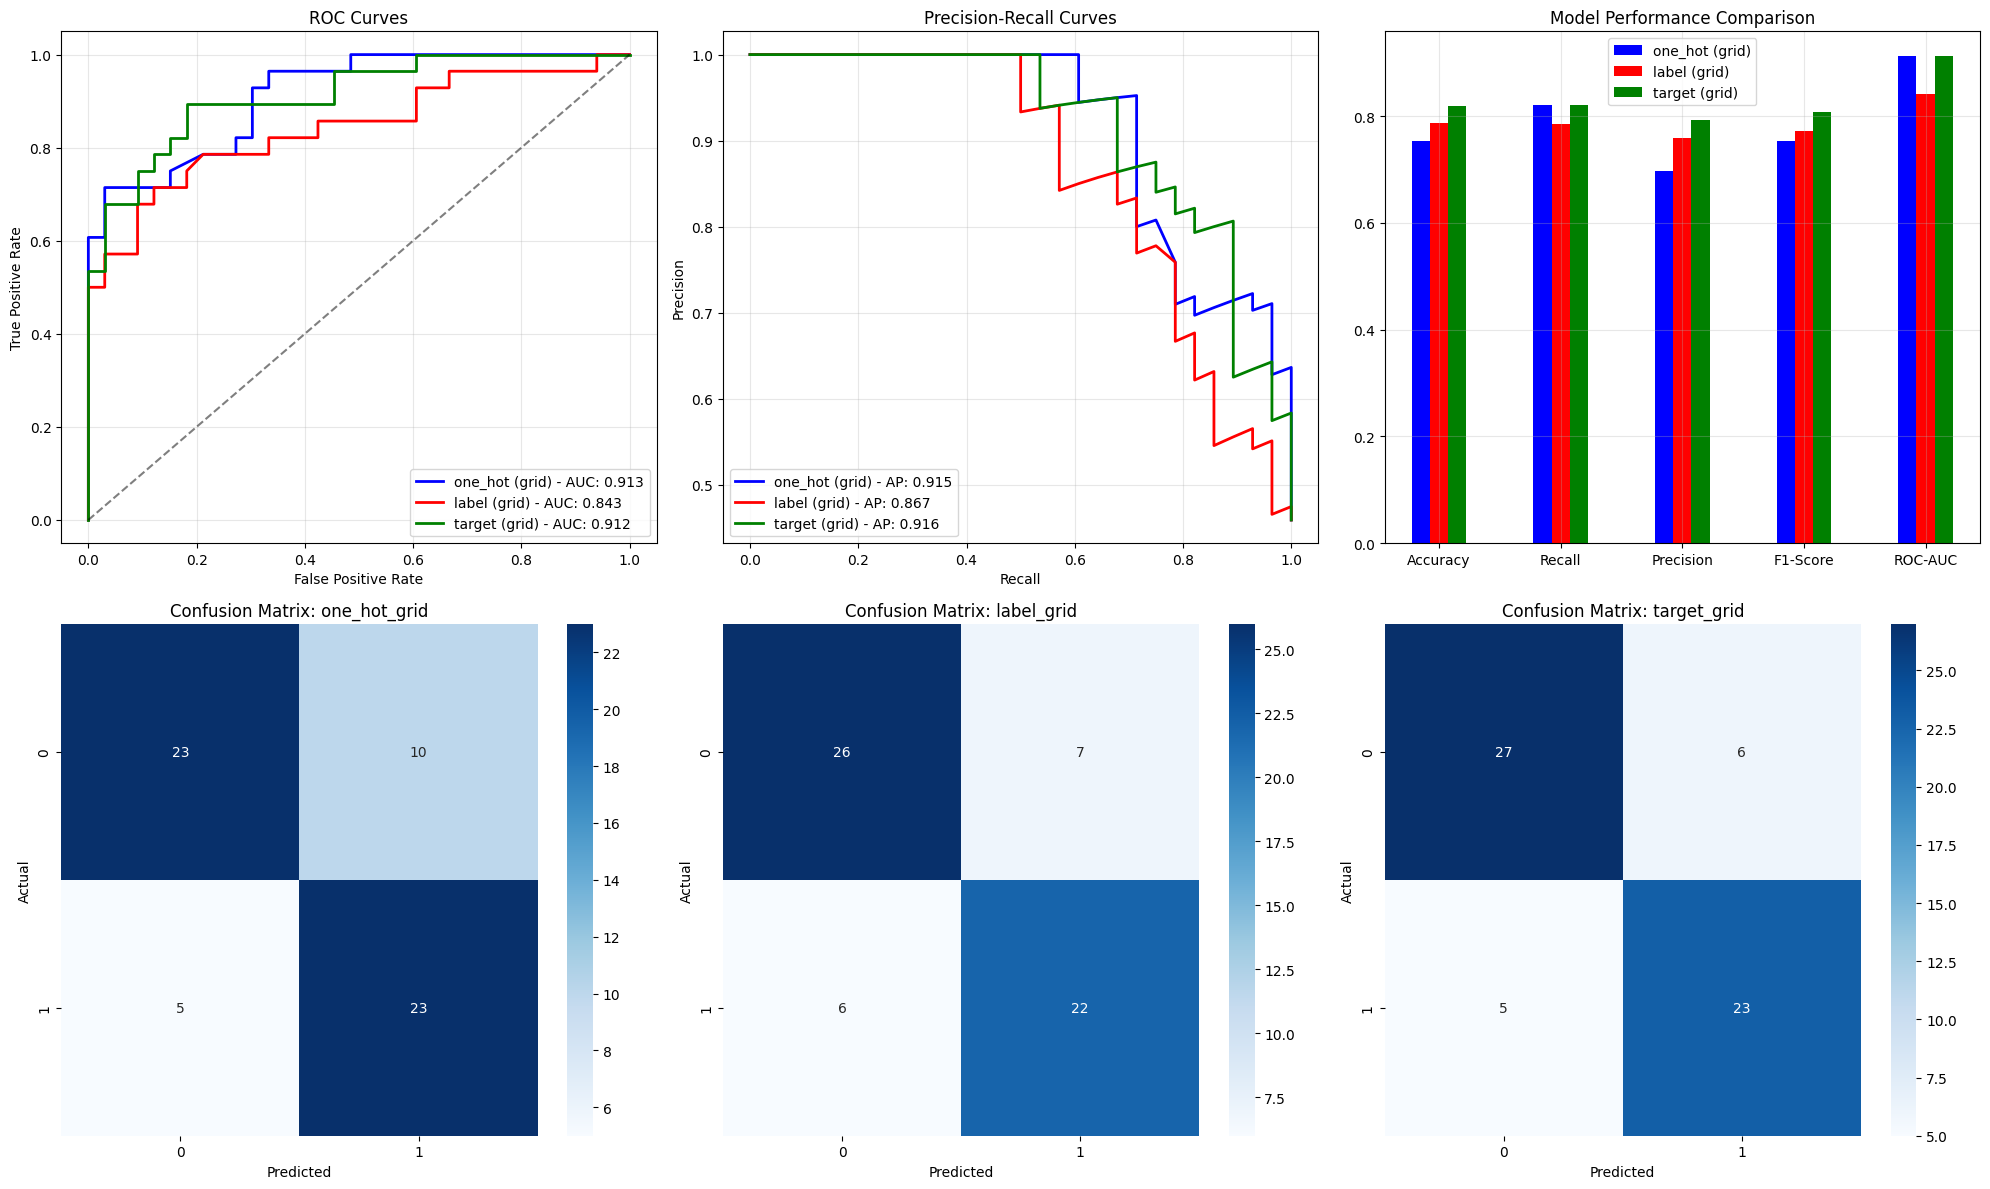

In [ ]:
# --- CELL 10: Comprehensive Visualization ---
def plot_comprehensive_results(results, y_test, test_data_dict):
    """
    Create comprehensive visualizations for all models.
    Args:
        results: Dictionary containing model results
        y_test: True labels for test set
        test_data_dict: Dictionary mapping encoding types to X_test datasets
                        e.g., {'one_hot': X_test_ohe, 'label': X_test_le}
    """
    # Increased figure size for 3 rows
    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    
    # Colors for different encodings
    colors = {'one_hot': 'blue', 'label': 'red', 'target': 'green'}
    
    def get_encoding_type(k):
        if 'one_hot' in k: return 'one_hot'
        if 'label' in k: return 'label'
        if 'target' in k: return 'target'
        return 'unknown'

    # --- ROW 1: SUMMARY CHARTS ---

    # 1. ROC Curves
    ax = axes[0, 0]
    for key, result in results.items():
        encoding_type = get_encoding_type(key)
        optimization = key.split('_')[-1]
        if encoding_type not in colors: continue
            
        color = colors[encoding_type]
        linestyle = '-' if optimization == 'grid' else '--'
        
        fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
        ax.plot(fpr, tpr, color=color, linestyle=linestyle, linewidth=2, 
                label=f'{encoding_type} ({optimization}) - AUC: {result["roc_auc"]:.3f}')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title('ROC Curves')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Precision-Recall Curves
    ax = axes[0, 1]
    for key, result in results.items():
        encoding_type = get_encoding_type(key)
        optimization = key.split('_')[-1]
        if encoding_type not in colors: continue

        color = colors[encoding_type]
        linestyle = '-' if optimization == 'grid' else '--'
        
        precision, recall, _ = precision_recall_curve(y_test, result['y_pred_proba'])
        ax.plot(recall, precision, color=color, linestyle=linestyle, linewidth=2, 
                label=f'{encoding_type} ({optimization}) - AP: {result["avg_precision"]:.3f}')
    
    ax.set_title('Precision-Recall Curves')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Metrics Comparison
    ax = axes[0, 2]
    metrics = ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']
    metric_names = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'ROC-AUC']
    x = np.arange(len(metrics))
    width = 0.15
    
    valid_keys = [k for k in results.keys() if get_encoding_type(k) in colors]
    
    for i, key in enumerate(valid_keys):
        encoding_type = get_encoding_type(key)
        optimization = key.split('_')[-1]
        color = colors[encoding_type]
        alpha = 1.0 if optimization == 'grid' else 0.7
        
        values = [results[key][metric] for metric in metrics]
        ax.bar(x + i*width, values, width, label=f'{encoding_type} ({optimization})', 
               color=color, alpha=alpha)
    
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x + width*len(valid_keys)/2 - width/2)
    ax.set_xticklabels(metric_names)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # --- CONFUSION MATRICES HELPER ---
    def plot_cm(ax, key_suffix, row_title):
        encodings = ['one_hot', 'label', 'target']
        for i, enc in enumerate(encodings):
            ax_curr = axes[ax, i]
            key = f"{enc}_{key_suffix}"
            
            if key in results and enc in test_data_dict:
                try:
                    model = results[key]['model']
                    X_input = test_data_dict[enc]
                    y_pred = model.predict(X_input)
                    
                    cm = confusion_matrix(y_test, y_pred)
                    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_curr, cbar=False)
                    ax_curr.set_title(f'{row_title}: {enc}')
                    ax_curr.set_xlabel('Predicted')
                    ax_curr.set_ylabel('Actual')
                except Exception as e:
                    ax_curr.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center')
                    ax_curr.axis('off')
            else:
                ax_curr.text(0.5, 0.5, f"No Data\n{key}", ha='center', va='center')
                ax_curr.axis('off')

    # --- ROW 2: GRID SEARCH CONFUSION MATRICES ---
    plot_cm(1, 'grid', 'Grid Search')

    # --- ROW 3: BAYESIAN OPTIMIZATION CONFUSION MATRICES ---
    plot_cm(2, 'bayes', 'Bayesian Opt')

    plt.tight_layout()
    plt.show()

# Define test data dictionary
my_test_data = {
    'one_hot': X_test_oh,
    'label':   X_test_le,
    'target':  X_test_te
}

# Run plotting function
plot_comprehensive_results(results, y_test, my_test_data)

In [13]:
# --- CELL 11: Results Summary and Analysis ---
print("="*70)
print("FINAL SVM ANALYSIS SUMMARY")
print("="*70)

# Create summary dataframe
summary_data = []
for key, result in results.items():
    enc_name = key.replace('_grid', '').replace('_bayes', '').replace('_', ' ')
    
    summary_data.append({
        'Encoding': enc_name,
        'Optimization': key.split('_')[-1],
        'Accuracy': f"{result['accuracy']:.4f}",
        'Recall': f"{result['recall']:.4f}",
        'Precision': f"{result['precision']:.4f}",
        'F1-Score': f"{result['f1']:.4f}",
        'ROC-AUC': f"{result['roc_auc']:.4f}",
        'Avg Precision': f"{result['avg_precision']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nDetailed Performance Summary:")
print(summary_df.to_string(index=False))

# Find best model based on Recall
best_model_recall = max(results.items(), key=lambda x: x[1]['recall'])
best_model_f1 = max(results.items(), key=lambda x: x[1]['f1'])

print(f"\n⭐ BEST MODEL BY RECALL: {best_model_recall[0]}")
print(f"   Recall: {best_model_recall[1]['recall']:.4f}")
print(f"   F1-Score: {best_model_recall[1]['f1']:.4f}")

print(f"\n⭐ BEST MODEL BY F1-SCORE: {best_model_f1[0]}")
print(f"   F1-Score: {best_model_f1[1]['f1']:.4f}")
print(f"   Recall: {best_model_f1[1]['recall']:.4f}")

# Compare encoding methods
encoding_performance = {}
for encoding in ['one_hot', 'label', 'target']:
    encoding_results = [v for k, v in results.items() if k.startswith(encoding)]
    if encoding_results:
        avg_recall = np.mean([r['recall'] for r in encoding_results])
        encoding_performance[encoding] = avg_recall

best_encoding = max(encoding_performance.items(), key=lambda x: x[1])
print(f"\n📊 BEST ENCODING METHOD (Average Recall): {best_encoding[0]}")
print(f"   Average Recall: {best_encoding[1]:.4f}")

# Compare optimization methods
grid_results = [v for k, v in results.items() if k.endswith('grid')]
bayes_results = [v for k, v in results.items() if k.endswith('bayes')]

avg_grid_recall = np.mean([r['recall'] for r in grid_results])
avg_bayes_recall = np.mean([r['recall'] for r in bayes_results])

print(f"\n⚙️ OPTIMIZATION METHOD COMPARISON:")
print(f"   GridSearchCV Average Recall: {avg_grid_recall:.4f}")
print(f"   Bayesian Optimization Average Recall: {avg_bayes_recall:.4f}")

FINAL SVM ANALYSIS SUMMARY

Detailed Performance Summary:
Encoding Optimization Accuracy Recall Precision F1-Score ROC-AUC Avg Precision
 one hot         grid   0.7541 0.8214    0.6970   0.7541  0.9134        0.9151
   label         grid   0.7869 0.7857    0.7586   0.7719  0.8425        0.8669
  target         grid   0.8197 0.8214    0.7931   0.8070  0.9123        0.9165

⭐ BEST MODEL BY RECALL: one_hot_grid
   Recall: 0.8214
   F1-Score: 0.7541

⭐ BEST MODEL BY F1-SCORE: target_grid
   F1-Score: 0.8070
   Recall: 0.8214

📊 BEST ENCODING METHOD (Average Recall): one_hot
   Average Recall: 0.8214

⚙️ OPTIMIZATION METHOD COMPARISON:
   GridSearchCV Average Recall: 0.8095
   Bayesian Optimization Average Recall: nan
